## Frozen-Layer Finetuning

By Jenna Beauchain

**Introduction:**

Frozen-Layer finetuning is a method where the earlier layers of a pretrained model are kept fixed, while only the later and more task specific layers are updated during training. In this project, this approach was used to preserve low-level features learned from the original dataset while allowing the model to learn task-specific patterns for cropland data. This was implemented by modifying the Fieldmapper YAML to freeze selected layers of the model, ensuring that only later layers were updated during training.

**Methods:**

The frozen-layer finetuning method was first implemented by updating the Fieldmapper framework to freeze the earlier layers of the model and allow the later layers to update. The code we updated can be seen below:

In [ ]:
## parameters for data loading and model specification
Train_Validate:

    # data loader parameters
    data_path: '/opt/app-root/src/projects' #/home/airg/data/labels/cropland'
    log_dir: '/opt/app-root/src/projects/transductivefeaturemaps/workdir/frozenlayerfinetune/v1/logs' #'/home/airg/rabedi/thesis/fieldmapper/work_dir/finetune/exp2_AWS_best_ema/logs'



    train_csv_name: '/opt/app-root/src/projects/transductivefeaturemaps/workdir/frozenlayerfinetune/v1/croplands3-2.1.1_finetune_ZM_only.csv'
    # '/home/airg/rabedi/thesis/fieldmapper/croplands3-2.1.1_finetune_all_samples.csv'

    data_size: 224  # Size of chips that is not buffered. (i.e., the size of labels)
    buffer: 0  # one_side_buffer
    buffer_comp: 0  # Buffer used when creating composite
    img_path_cols: ['image']
    label_path_col: 'label'
    label_group: [0, 1, 2, 3, 4, 5]
    apply_normalization: True
    normal_strategy: "min_max"
    stat_procedure: 'lab'
    global_stats: null
    catalog_index: null
    trans: null
    parallel: null


    # explicilty pass the default values for the following **kwargs
    scale_factor: (0.75, 1.5)
    crop_strategy: "center"
    rotation_degree: (-180, -90, 90, 180)
    #bshiift_subs:  # this was not defined and used in datatorch.py
    sigma_range: [0.03, 0.07]
    br_range: [-0.02, 0.02]
    contrast_range: [0.9, 1.2]
    bshift_gamma_range: (0.2, 2.0)
    patch_shift: True
    downfactor: 32
    clip_val: 0
    nodata: []


    train_batch: 16
    validate_batch: 4


    # model compiler parameters
    model: unet_att_d #attn_unet_d
    model_compiler_buffer: 0
    class_mapping: {0: 'non-field', 1: 'field', 2: 'field boundary'}
    model_working_dir: '/opt/app-root/src/projects/transductivefeaturemaps/workdir/frozenlayerfinetune/v1'
    #'/home/airg/rabedi/thesis/fieldmapper/work_dir/finetune/exp2_AWS_best_ema'
    gpu_devices: [0] # [0, 1, 2]
    use_sync_bn: False
    model_init_type: "kaiming"
    params_init: '/opt/app-root/src/projects/model/best_model_pretrain-001.pth'
    #'/home/airg/rabedi/thesis/fieldmapper/work_dir/pretrain/exp1_AWS/best_ema_state.pth'
    ##progressive finetuning
    freeze_params: [0,1,2,3,4,5] #list(range(10))
    progressive_unfreeze: False      # turn on/off (default: off if absent)
    epochs_per_stage: 13            # unfreeze cadence
    unfreeze_direction: deep     # shallow or deep
    max_unfreeze_stages: 6
    #######
    n_classes: 3
    channels: 4


    model_kwargs: {filter_config:  [64, 256, 512, 1024, 2048, 4096],
                   block_num: [2, 2, 2, 2, 2, 2],
                   dropout_rate: 0.1,
                   dropout_type: 'traditional',
                   upmode: 'deconv_2',
                   use_skipAtt: False}


    epoch: 10
    optimizer_name: SAM
    learning_rate_init: 0.02
    learning_rate_policy: "StepLR"
    criterion: LocallyWeightedTverskyFocalLoss()
    momentum: 0.95
    resume: False
    checkpoint_interval: 20
    resume_epoch: null
    early_stopping_patience: 10
    min_delta: 0.001
    warmup_period: 10


    val_metric_fname: finetune_metrics.csv
    model_out_dir: '/opt/app-root/src/projects/transductivefeaturemaps/workdir/frozenlayerfinetune/v1/checkpoints' #'/home/airg/rabedi/thesis/fieldmapper/work_dir/finetune/exp2_AWS_best_ema/'

Test:
  separate_test_csv: null
  saved_params: null






From the originial Fieldmapper code, I changed a few parameters to create frozen-layer finetuning. The first thing I changed was the paths for log_fir, model_working_dir, and model_out_dir to reflect the path of our code with the folders created called workdir. Workdir contains each different finetuning method and the results. In addition, I changed the CSV to reflect only the Zambia data as shown in the description document. I changed freeze_parms from null to [0,1,2,3,4,5] which prevents the model from updating the earlier layers as well as turned the progressive unfreeze off. Lastly, to keep the models as similar as possible for the comparison, all three finetuning models used 10 epochs, SAM as the optimizer, a training batch of 16, and a validation batch of 4.

**Results/analysis:**

After running this model, we used matplotlib to help visualize our results. In the code below:

In [ ]:
##Visualizations for Zambia Data (Frozen-Layer Finetuning)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [ ]:
history = pd.read_csv('v1/checkpoints/unet_att_d_ep10/training_history.csv')
metrics = pd.read_csv('v1/checkpoints/finetune_metrics.csv')
classwise = pd.read_csv('v1/checkpoints/finetune_metrics_classwise.csv')

print('Training history shape:', history.shape)
print(history.head())
print('\nOverall metrics:')
print(metrics)
print('\nClass-wise metrics:')
print(classwise)

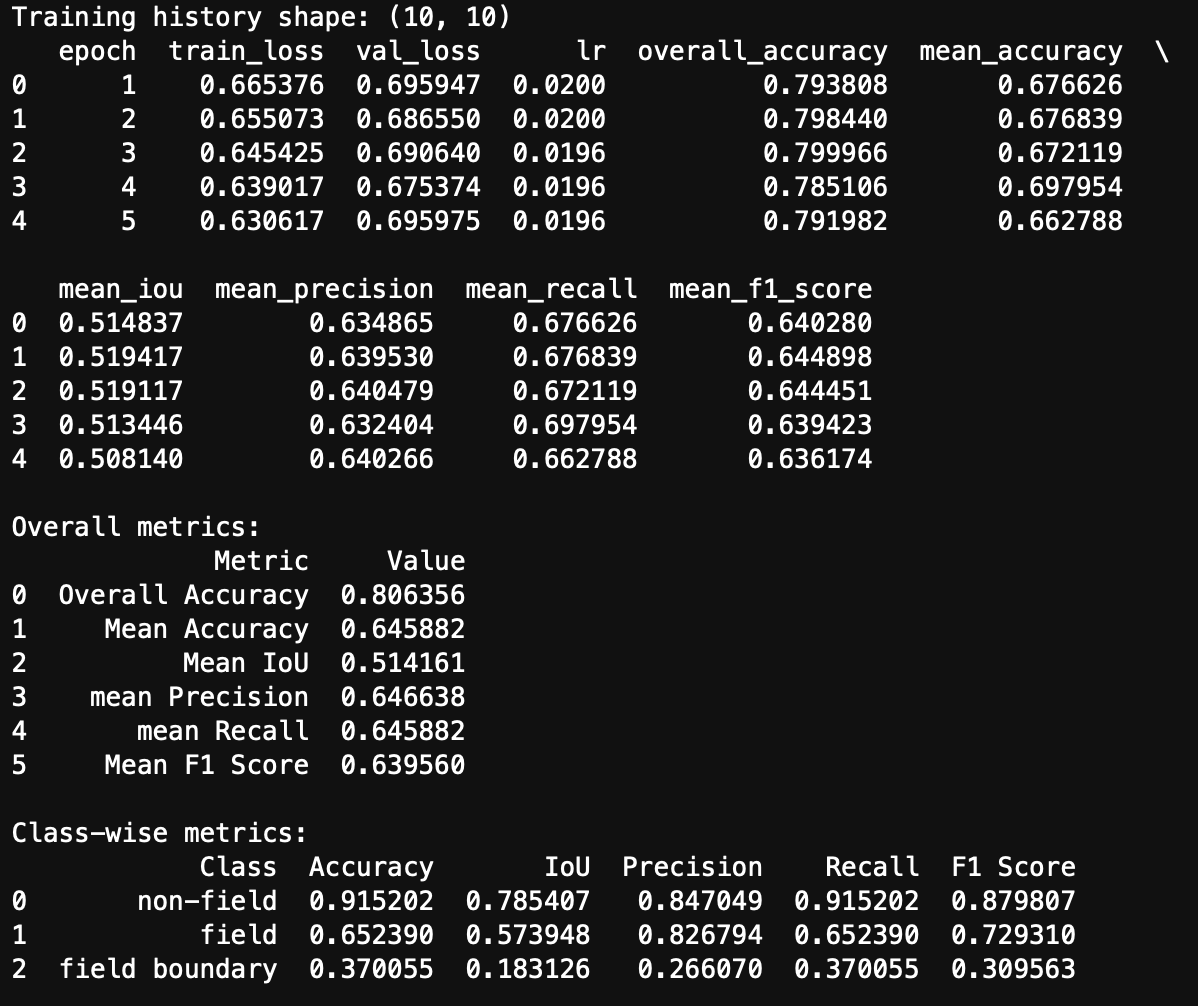

In [ ]:
##Loss Curves (Train vs Validation)

In [ ]:
epochs = history['epoch']
best_epoch = history['val_loss'].idxmin() + 1  # 1-indexed
best_val   = history['val_loss'].min()

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(epochs, history['train_loss'], 'o-', color='steelblue',  label='Train loss',      linewidth=2, markersize=5)
ax.plot(epochs, history['val_loss'],   's-', color='darkorange', label='Validation loss', linewidth=2, markersize=5)

# Mark best validation epoch
ax.axvline(best_epoch, color='darkorange', linestyle='--', alpha=0.5, linewidth=1.2)
ax.annotate(f'Best val\nEpoch {best_epoch}\n({best_val:.4f})',
            xy=(best_epoch, best_val), xytext=(best_epoch + 0.4, best_val + 0.005),
            fontsize=9, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1))

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Validation Loss', fontweight='bold')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', bbox_inches='tight')
plt.show()
print('Saved → loss_curves.png')

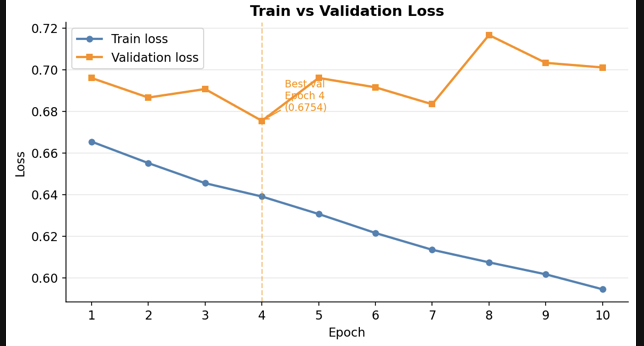

In [ ]:
##Learning Rate Schedule

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.step(epochs, history['lr'], where='post', color='mediumseagreen', linewidth=2)
ax.fill_between(epochs, history['lr'], step='post', alpha=0.15, color='mediumseagreen')

# Annotate each unique LR
prev = None
for _, row in history.iterrows():
    if row['lr'] != prev:
        ax.annotate(f"{row['lr']:.5g}", xy=(row['epoch'], row['lr']),
                    xytext=(0, 6), textcoords='offset points',
                    fontsize=8, ha='center', color='darkgreen')
        prev = row['lr']

ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule', fontweight='bold')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('lr_schedule.png', bbox_inches='tight')
plt.show()
print('Saved → lr_schedule.png')

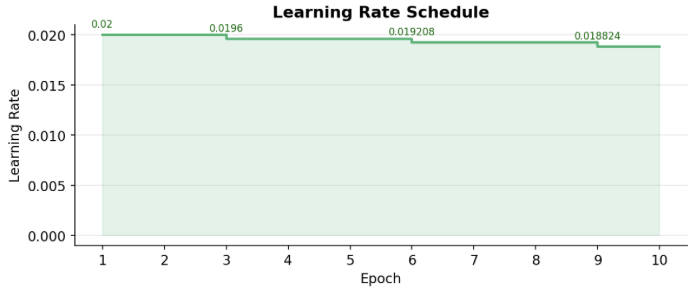

In [ ]:
##Validation Metrics per Epoch

In [ ]:
val_metrics = [
    ('overall_accuracy', 'Overall Accuracy', 'royalblue'),
    ('mean_accuracy',    'Mean Accuracy',    'tomato'),
    ('mean_iou',         'Mean IoU',         'gold'),
    ('mean_f1_score',    'Mean F1',          'mediumorchid'),
    ('mean_precision',   'Mean Precision',   'teal'),
    ('mean_recall',      'Mean Recall',      'coral'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
axes = axes.flatten()

for ax, (col, label, color) in zip(axes, val_metrics):
    ax.plot(epochs, history[col], 'o-', color=color, linewidth=2, markersize=5)
    best_idx = history[col].idxmax()
    ax.scatter(history.loc[best_idx, 'epoch'], history.loc[best_idx, col],
               s=80, zorder=5, color=color, edgecolors='black', linewidth=1)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xlabel('Epoch')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1)

fig.suptitle('Validation Metrics per Epoch', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('val_metrics_per_epoch.png', bbox_inches='tight')
plt.show()
print('Saved → val_metrics_per_epoch.png')

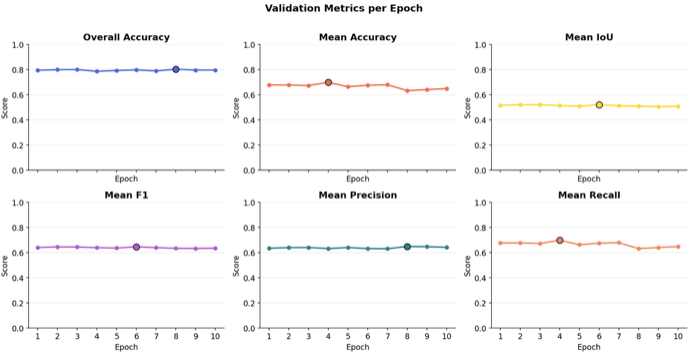

In [ ]:
print(history.columns)

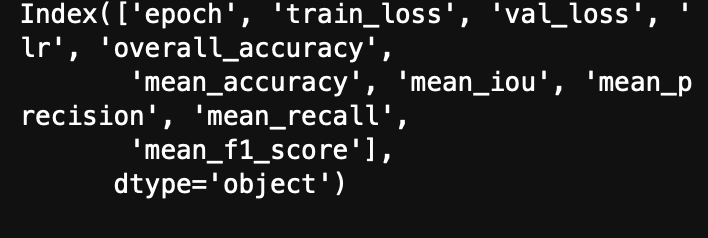

In [ ]:
##Overall Metrics

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ['royalblue', 'tomato', 'gold', 'teal', 'coral', 'mediumorchid']
bars = ax.barh(metrics['Metric'], metrics['Value'], color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, metrics['Value']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlim(0, 1.05)
ax.set_xlabel('Score')
ax.set_title('Final Evaluation — Overall Metrics', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('overall_metrics.png', bbox_inches='tight')
plt.show()
print('Saved → overall_metrics.png')

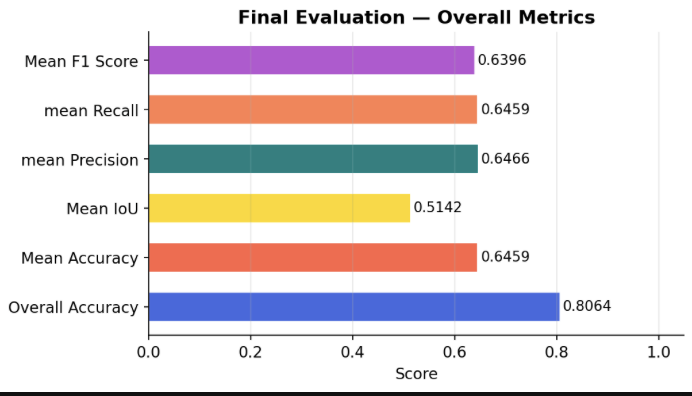

In [ ]:
##Classwise Metrics

In [ ]:
cw_metrics = ['Accuracy', 'IoU', 'Precision', 'Recall', 'F1 Score']
classes    = classwise['Class'].tolist()
x          = np.arange(len(classes))
width      = 0.15
colors     = ['steelblue', 'darkorange', 'mediumseagreen', 'tomato', 'mediumorchid']

fig, ax = plt.subplots(figsize=(10, 5))

for i, (metric, color) in enumerate(zip(cw_metrics, colors)):
    offset = (i - 2) * width
    rects = ax.bar(x + offset, classwise[metric], width, label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Class-wise Evaluation Metrics', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('classwise_metrics.png', bbox_inches='tight')
plt.show()
print('Saved → classwise_metrics.png')

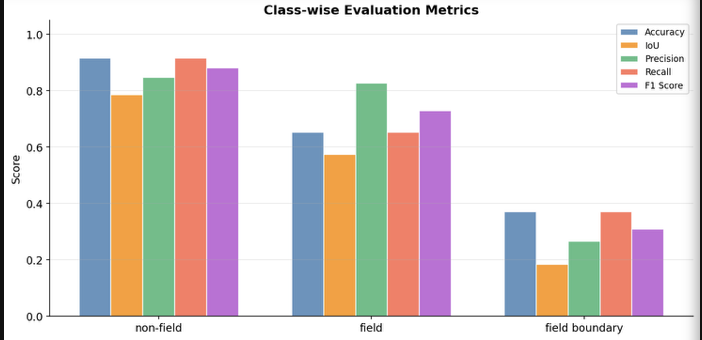

In [ ]:
##Summary Dashboard

In [ ]:
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# --- Loss curves (top-left, span 2 cols) ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(epochs, history['train_loss'], 'o-', color='steelblue',  label='Train',      lw=2, ms=4)
ax1.plot(epochs, history['val_loss'],   's-', color='darkorange', label='Validation', lw=2, ms=4)
ax1.axvline(best_epoch, color='darkorange', ls='--', alpha=0.4, lw=1)
ax1.set_title('Loss Curves', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- LR schedule (top-right) ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.step(epochs, history['lr'], where='post', color='mediumseagreen', lw=2)
ax2.fill_between(epochs, history['lr'], step='post', alpha=0.15, color='mediumseagreen')
ax2.set_title('LR Schedule', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('LR')
ax2.grid(axis='y', alpha=0.3)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- Val metrics per epoch (middle row) ---
mid_metrics = [('overall_accuracy','Overall Acc','royalblue'),
               ('mean_iou','Mean IoU','gold'),
               ('mean_f1_score','Mean F1','mediumorchid')]
for j, (col, lbl, clr) in enumerate(mid_metrics):
    ax = fig.add_subplot(gs[1, j])
    ax.plot(epochs, history[col], 'o-', color=clr, lw=2, ms=4)
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
    ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- Class-wise bars (bottom row, full width) ---
ax_cw = fig.add_subplot(gs[2, :])
for i, (metric, color) in enumerate(zip(cw_metrics, colors)):
    offset = (i - 2) * width
    ax_cw.bar(x + offset, classwise[metric], width, label=metric, color=color, alpha=0.85, edgecolor='white')
ax_cw.set_xticks(x)
ax_cw.set_xticklabels(classes)
ax_cw.set_ylim(0, 1.05)
ax_cw.set_ylabel('Score')
ax_cw.set_title('Class-wise Evaluation Metrics', fontweight='bold')
ax_cw.legend(loc='upper right', fontsize=9)
ax_cw.grid(axis='y', alpha=0.3)

fig.suptitle('ZM Finetune — Training Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('training_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved → training_dashboard.png')

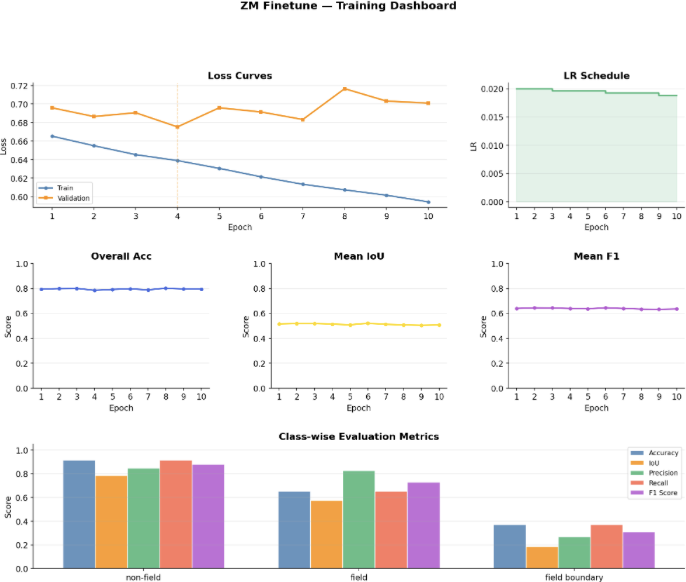

**Discussion:**

The frozen-layer finetuning method demonstrates limited performance improvements when it was applied to the Zambia (ZM) cropland dataset.

The loss curve model shows the training loss steadily decreasing, with the loss reaching its minimum around epoch number 4. This indicates that it is mildly overfitting after the first few epochs and that the model possibly cannot fully adapt with the frozen layers. The learning rate decreased slightly over time but remained fairly stable throughout all the epochs and mainly affected the final layers. The validation metrics show that the overall accuracy is around 0.80 percent which shows high and stable accuracy. The Mean IoU and F1, 0.51 and 0.64 respectively, show that the segmentation quality is moderate and possible difficulty with precise pixel predictions. The class-wise performance shows strong performancen for the non-field class, moderate performance for the field class, and weak performance for the field boundary class. This is likely the result of the model struggling with edges or fine spatial details.

From these models we can conclude that the results suggest preserving pretrained low-level features while only updating higher-level layers allows the model to generalize well but often restricts the models ability to adapt to specific patterns.

**Resources:**

https://medium.com/@prabhatzade/freezing-layers-and-fine-tuning-transformer-models-in-pytorch-a-simple-guide-119cad0980c6

https://www.byhand.ai/p/library-models-fine-tuning-frozen-layers

**ChatGPT Link**

https://chatgpt.com/share/69f935da-1f7c-83ea-bf9a-3b149470da96